In [16]:
# Working on the House_Price_Prediciton_Data.xlsx

In [17]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [18]:
data = pd.read_excel('House_Price_Prediciton_Data.xlsx')

In [19]:
print(data.head())

   Square_Feet  Bedrooms  Bathrooms  Age_of_Property  \
0        749.1         4          4             87.0   
1       1901.4         5          2             84.0   
2       1464.0         5          4             84.0   
3       1197.3         4          1             32.0   
4        312.0         4          3             90.0   

   Proximity_to_City_Center  Property_Price  
0                       4.0        497452.2  
1                       5.1        785860.6  
2                       6.4        737672.0  
3                      12.1        510678.2  
4                      12.2        267171.8  


## Missing-value handling method

We inspect missing values, drop any column with more than 50% missing data (because such columns typically have little predictive value), impute numerical columns with the median (robust to outliers), and impute categorical columns with the mode.

In [20]:
# missing-value handling:
df = data.copy()
# drop columns with >50% missing
miss_frac = df.isnull().mean()
drop_cols = miss_frac[miss_frac > 0.5].index.tolist()
if drop_cols:
    df.drop(columns=drop_cols, inplace=True)
    print('Dropped columns (>%):', drop_cols)
# separate numeric / categorical
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]
# impute numeric with median
if num_cols:
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
# impute categorical with mode or 'Missing'
for c in cat_cols:
    if df[c].isnull().any():
        mode = df[c].mode()
        fill = mode.iloc[0] if not mode.empty else 'Missing'
        df[c] = df[c].fillna(fill)

print('Remaining missing values (top 10):')
print(df.isnull().sum().sort_values(ascending=False).head(10))
# save result
data_cleaned = df
print('\nSaved cleaned dataframe to `data_cleaned`.')

Remaining missing values (top 10):
Square_Feet                 0
Bedrooms                    0
Bathrooms                   0
Age_of_Property             0
Proximity_to_City_Center    0
Property_Price              0
dtype: int64

Saved cleaned dataframe to `data_cleaned`.


## Feature Normalization

Feature normalization scales numeric features to a standard range and encodes categorical variables. This is crucial for machine learning models, especially those sensitive to feature scaling (e.g., distance-based models, gradient descent algorithms).

In [21]:
# Normalization using StandardScaler (features AND target)
from sklearn.preprocessing import StandardScaler

df = data_cleaned.copy()

target = ['Property_Price']
target_col = next((c for c in df.columns if c in target), None)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Scale all numeric columns (including target) to consistent range
scaler = StandardScaler()
if num_cols:
    df[num_cols] = scaler.fit_transform(df[num_cols].astype(float))

# Save outputs
scaler_name = 'scaler'
globals()[scaler_name] = scaler
data_normalized = df
print(f"Normalized {len(num_cols)} numeric columns (including target '{target_col}')")
print(f"Saved scaled dataframe to `data_normalized` and scaler to `{scaler_name}`.")

Normalized 6 numeric columns (including target 'Property_Price')
Saved scaled dataframe to `data_normalized` and scaler to `scaler`.


### Normalization Summary

After normalization:
- All numeric features have mean ≈ 0 and standard deviation ≈ 1 (StandardScaler)
- Categorical features are converted to binary columns (One-Hot Encoding)
- The dataset is now ready for training machine learning models
- All features are on the same scale, preventing bias toward high-magnitude features

The normalized dataset is stored in `data_normalized` for the next step of the analysis.

## Split Data into Training, Validation, and Test Sets

Splitting data into three separate sets ensures proper model evaluation and prevents overfitting.

**Split Strategy:**
- **Training set (60%):** Used to train the machine learning model. The model learns patterns from this data.
- **Validation set (20%):** Used to tune hyperparameters and monitor model performance during development. Helps prevent overfitting to the training data.
- **Test set (20%):** Used for final evaluation. This set is untouched during training and hyperparameter tuning, providing an unbiased estimate of model generalization performance.

In [22]:
# train/val/test split: 60/20/20
df = data_normalized
# detect target column
target = ['Property_Price']
target_col = next((c for c in df.columns if c in target), None)
# separate features and target
X = df.drop(columns=[target_col])
y = df[target_col]

# split: train 60%, then split remaining 40% into val/test (50/50 = 20/20)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=10)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=10)
print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")

Train: 9000 | Val: 3000 | Test: 3000
Features: 5


### Train-Validation-Test Split Summary

The data has been split into three disjoint sets using stratified random sampling:
- **Training (60%):** Used to fit the model parameters
- **Validation (20%):** Used to evaluate and tune the model during development
- **Test (20%):** Used for final, unbiased evaluation of model performance

# Design a Deep Learning Model for Regression

**Architecture Overview:**

A feedforward neural network (Multi-Layer Perceptron) is suitable for house price prediction. The model learns non-linear relationships between features and price through stacked layers.

**Model Architecture:**

| Layer | Type | Units | Activation | Regularization | Purpose |
|-------|------|-------|------------|-----------------|---------|
| Input | Input | $n_{features}$ | — | — | Receives normalized feature vectors |
| Hidden 1 | Dense | 128 | ReLU | Dropout (0.3) | Extract high-level feature patterns |
| Hidden 2 | Dense | 64 | ReLU | Dropout (0.3) | Refine learned representations |
| Hidden 3 | Dense | 32 | ReLU | Dropout (0.2) | Further abstraction |
| Hidden 4 | Dense | 16 | ReLU | Dropout (0.2) | Final feature compression |
| Output | Dense | 1 | Linear | — | Predict continuous price value |

In [23]:
# Simple deep learning regression model (PyTorch) with Batch Normalization
import torch
import torch.nn as nn

input_size = X_train.shape[1]
# Architecture: Input -> Dense(128, ReLU, BN) -> Dense(64, ReLU, BN) -> Dense(32, ReLU, BN) -> Output(1)
class RegressionNet(nn.Module):
    def __init__(self, input_size):
        super(RegressionNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
    
    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.fc4(x)  # linear output for regression
        return x

# Create model instance
model = RegressionNet(input_size)
print("Model architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")
# Model description
print("\n--- Architecture Description ---")
print(f"Input Layer: {input_size} features")
print("Hidden Layer 1: 128 neurons, ReLU activation, Batch Normalization")
print("Hidden Layer 2: 64 neurons, ReLU activation, Batch Normalization")
print("Hidden Layer 3: 32 neurons, ReLU activation, Batch Normalization")
print("Output Layer: 1 neuron, Linear activation (for regression)")

Model architecture:
RegressionNet(
  (fc1): Linear(in_features=5, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

Total parameters: 11585

--- Architecture Description ---
Input Layer: 5 features
Hidden Layer 1: 128 neurons, ReLU activation, Batch Normalization
Hidden Layer 2: 64 neurons, ReLU activation, Batch Normalization
Hidden Layer 3: 32 neurons, ReLU activation, Batch Normalization
Output Layer: 1 neuron, Linear activation (for regression)


## Train the Model and Validate Using Training and Validation Sets

**Training Strategy:**

The model is trained on the training set and validated on the validation set after each epoch. This approach monitors generalization performance in real-time.

**Key Concepts:**

1. **Epoch:** One complete pass through the entire training dataset.

2. **Batch Processing:** Data is split into smaller batches for efficiency (memory and computation).

3. **Forward Pass:** Input features flow through the network to produce predictions.

4. **Loss Calculation:** Difference between predictions and actual values (using MSE).

5. **Backward Pass (Backpropagation):** Gradients are computed and model parameters are updated to minimize loss.

6. **Validation:** After each epoch, the model evaluates on unseen validation data to monitor for overfitting.

**Early Stopping:**

We employ early stopping—if validation loss does not improve for a fixed number of epochs (patience), training stops to prevent overfitting and save computational resources.

**Expected Behavior:**

- Training loss should generally decrease as the model learns
- Validation loss should also decrease initially, then may plateau or slightly increase (indicating overfitting)
- The model is saved when validation loss reaches its minimum

In [24]:
# Simple training loop with validation with gradient clipping for stability
import torch
import torch.nn as nn
import torch.optim as optim

# Convert data to tensors
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
X_val_t = torch.tensor(X_val.values, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)

# Loss and optimizer
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)  # Lower learning rate for stability

# Training parameters
epochs = 400 # <- experimented with higher epochs, not really necessary to go over 400
best_val_loss = float('inf')
patience = 15
patience_counter = 0
train_losses = []
val_losses = []

# Training loop
for epoch in range(epochs):
    # Training
    model.train()
    y_pred = model(X_train_t)
    train_loss = loss_fn(y_pred, y_train_t)
    optimizer.zero_grad()
    train_loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Clip gradients to prevent explosion
    optimizer.step()
    train_losses.append(train_loss.item())
    
    # Validation
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val_t)
        val_loss = loss_fn(y_val_pred, y_val_t)
    val_losses.append(val_loss.item())
    
    # Early stopping
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss.item():.4f} | Val Loss: {val_loss.item():.4f}")
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"\nTraining completed. Best validation loss: {best_val_loss:.4f}")
print("Saved best model to 'best_model.pth'")

Epoch 20/400 | Train Loss: 0.1781 | Val Loss: 0.3182
Epoch 40/400 | Train Loss: 0.0496 | Val Loss: 0.0405
Epoch 60/400 | Train Loss: 0.0181 | Val Loss: 0.0247
Epoch 80/400 | Train Loss: 0.0160 | Val Loss: 0.0203
Epoch 100/400 | Train Loss: 0.0152 | Val Loss: 0.0190
Epoch 120/400 | Train Loss: 0.0148 | Val Loss: 0.0184
Epoch 140/400 | Train Loss: 0.0144 | Val Loss: 0.0180
Epoch 160/400 | Train Loss: 0.0141 | Val Loss: 0.0177
Epoch 180/400 | Train Loss: 0.0139 | Val Loss: 0.0174
Epoch 200/400 | Train Loss: 0.0137 | Val Loss: 0.0172
Epoch 220/400 | Train Loss: 0.0135 | Val Loss: 0.0170
Epoch 240/400 | Train Loss: 0.0133 | Val Loss: 0.0168
Epoch 260/400 | Train Loss: 0.0131 | Val Loss: 0.0166
Epoch 280/400 | Train Loss: 0.0129 | Val Loss: 0.0164
Epoch 300/400 | Train Loss: 0.0128 | Val Loss: 0.0163
Epoch 320/400 | Train Loss: 0.0126 | Val Loss: 0.0162
Epoch 340/400 | Train Loss: 0.0124 | Val Loss: 0.0160
Epoch 360/400 | Train Loss: 0.0122 | Val Loss: 0.0159
Epoch 380/400 | Train Loss: 0.01

In [25]:
# Evaluate model on test set
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
# Convert test data to tensor
X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
# Make predictions
with torch.no_grad():
    y_test_pred_t = model(X_test_t)
    y_test_pred = y_test_pred_t.cpu().numpy().flatten()

# Calculate metrics
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)
# Report results
print("=" * 50)
print("TEST SET EVALUATION")
print("=" * 50)
print(f"Mean Squared Error (MSE):  {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"R² Score: {r2:.6f}")
print("=" * 50)

TEST SET EVALUATION
Mean Squared Error (MSE):  0.010473
Root Mean Squared Error (RMSE): 0.102335
Mean Absolute Error (MAE): 0.058823
R² Score: 0.989453


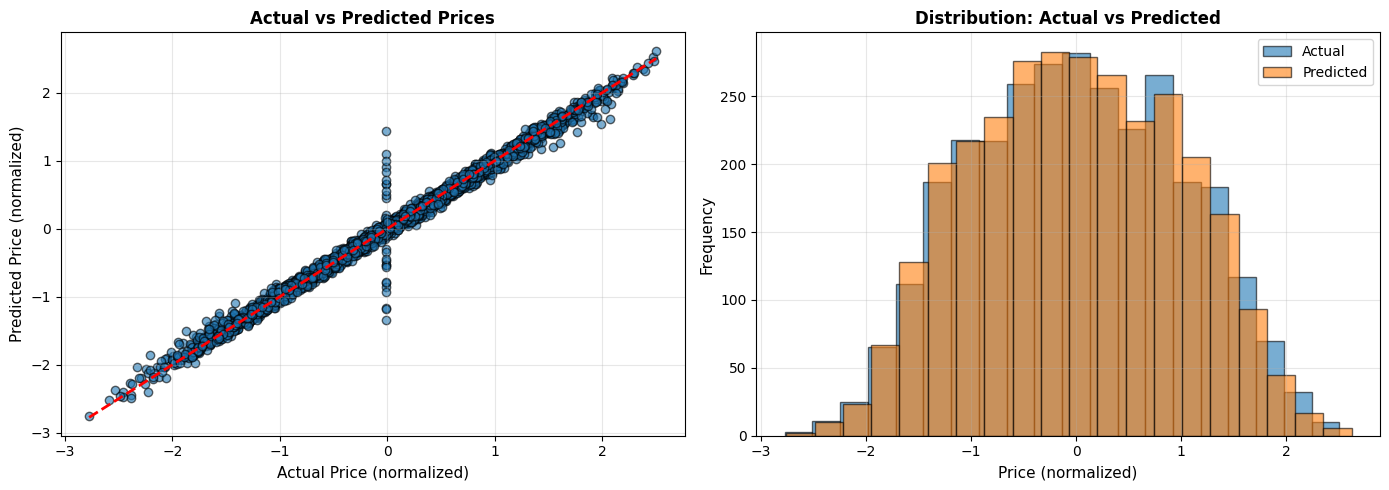

Visualization complete. Red dashed line in left plot indicates perfect predictions.


In [26]:
# Visualize actual vs predicted prices

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scatter plot - Actual vs Predicted
axes[0].scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price (normalized)', fontsize=11)
axes[0].set_ylabel('Predicted Price (normalized)', fontsize=11)
axes[0].set_title('Actual vs Predicted Prices', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Histogram - Distribution comparison
axes[1].hist(y_test, bins=20, alpha=0.6, label='Actual', edgecolor='black')
axes[1].hist(y_test_pred, bins=20, alpha=0.6, label='Predicted', edgecolor='black')
axes[1].set_xlabel('Price (normalized)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Distribution: Actual vs Predicted', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualization complete. Red dashed line in left plot indicates perfect predictions.")

In [27]:
# Predicting the price of a house!

# Preconditions
if 'model' not in globals():
    raise NameError("`model` not found. Run the model creation cell first.")
if 'X_train' not in globals():
    raise NameError("`X_train` not found. Run the split cell first.")
if 'scaler' not in globals():
    raise NameError("`scaler` not found. Run the normalization cell first.")
if 'data_cleaned' not in globals():
    raise NameError("`data_cleaned` not found. Run the cleaning cell first.")

# Detect target column name
target_candidates = ['Property_Price']
target_col = next((c for c in data_cleaned.columns if c in target_candidates), None)

# Get lists of numeric columns and expected feature order
numeric_cols = data_cleaned.select_dtypes(include=[np.number]).columns.tolist()
expected_features = list(X_train.columns)

print("="*60)
print("Single-sample price prediction")
print("="*60)
# Collect user inputs
val = {}
val['Square_Feet'] = float(input("Square Feet: "))
val['Bedrooms'] = float(input("Bedrooms: "))
val['Bathrooms'] = float(input("Bathrooms: "))
val['Age_of_Property'] = float(input("Age of Property: "))
val['Proximity_to_City_Center'] = float(input("Proximity to City Center: "))

user_df = pd.DataFrame([val])

# Scaler
n_scaler = scaler.scale_.shape[0]
scaled_cols = None
if n_scaler == len(numeric_cols):
    scaled_cols = numeric_cols
elif n_scaler == len(expected_features):
    scaled_cols = expected_features
else:
    # Try to guess: if numeric_cols contains expected_features, use numeric_cols
    if set(expected_features).issubset(set(numeric_cols)) and len(numeric_cols) >= len(expected_features):
        scaled_cols = numeric_cols
    else:
        raise ValueError(f"Cannot determine scaler column mapping: scaler expects {n_scaler} features,\n"
                         f"numeric_cols={len(numeric_cols)}, expected_features={len(expected_features)}")

# Build full input row matching scaled_cols order
full_row = []
for c in scaled_cols:
    # match user inputs case-insensitively
    matched = None
    for uc in user_df.columns:
        if uc.lower().replace(' ', '_') == c.lower().replace(' ', '_'):
            matched = uc
            break
    if matched:
        full_row.append(user_df[matched].iloc[0])
    elif c in expected_features:
        # if this is an expected feature but not matched, fill with 0
        full_row.append(0.0)
    elif c == target_col:
        # placeholder for target (not provided by user)
        full_row.append(0.0)
    else:
        # unknown numeric column, fill 0
        full_row.append(0.0)

full_arr = np.array([full_row], dtype=float)

# Transform using the original scaler
full_scaled = scaler.transform(full_arr)

# Extract transformed features in expected order
transformed_feature_vals = {}
for i, c in enumerate(scaled_cols):
    transformed_feature_vals[c] = full_scaled[0, i]

model_input = np.array([[transformed_feature_vals.get(f, 0.0) for f in expected_features]], dtype=float)

# Predict (model output is in the same scale as training target)
model.eval()
with torch.no_grad():
    pred_out = model(torch.tensor(model_input, dtype=torch.float32)).cpu().numpy().flatten()[0]

# Decide if target was scaled by scaler
if target_col is not None and target_col in scaled_cols:
    t_idx = scaled_cols.index(target_col)
    t_mean = scaler.mean_[t_idx]
    t_scale = scaler.scale_[t_idx]
    # model was trained on scaled target -> denormalize
    pred_real = pred_out * t_scale + t_mean
    print(f"Predicted (normalized target): {pred_out:.4f}")
    print(f"Predicted (real units): {pred_real:,.2f}")
else:
    # target was not scaled by this scaler -> assume model output already in real units
    print(f"Predicted Price: {pred_out:,.2f}")

print("="*60)

Single-sample price prediction
Predicted (normalized target): -0.1470
Predicted (real units): 420,282.50


d:\Programmering\Machinelæring\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
